# 02 — Analyse exploratoire des données — EDA

## Projet : Smart City Energy Forecasting — Tetouan


## Importation des bibliothèques et configuration visuelle

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "figure.figsize": (14, 6),
    "axes.titlesize": 14
})

FIG_DIR = Path("../results/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Chargement des données

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_tetouan_data
from src.preprocessing import resample_hourly

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Tetuan City power consumption.csv"

df = load_tetouan_data(
    DATA_PATH,
    set_datetime_index=True,
    strict_frequency=True,
)

print("Dimensions brutes :", df.shape)
print("Fréquence brute inférée :", pd.infer_freq(df.index))

print("\nValeurs manquantes :")
print(df.isna().sum())

df_hourly = resample_hourly(df, check_counts=True)

print("\nDimensions horaires :", df_hourly.shape)
print("Fréquence horaire inférée :", pd.infer_freq(df_hourly.index))

Dimensions brutes : (52416, 10)
Fréquence brute inférée : 10min

Valeurs manquantes :
temperature              0
humidity                 0
wind_speed               0
general_diffuse_flows    0
diffuse_flows            0
zone1_power              0
zone2_power              0
zone3_power              0
target                   0
total_load               0
dtype: int64

Dimensions horaires : (8736, 10)
Fréquence horaire inférée : h


## Rééchantillonnage horaire

In [3]:
# Rééchantillonnage horaire par moyenne
df_hourly = df.resample("1h").mean(numeric_only=True)

print(f"Dimensions après rééchantillonnage horaire : {df_hourly.shape}")
print("Fréquence horaire inférée :", pd.infer_freq(df_hourly.index))

print("\nValeurs manquantes après rééchantillonnage :")
print(df_hourly.isna().sum())

Dimensions après rééchantillonnage horaire : (8736, 10)
Fréquence horaire inférée : h

Valeurs manquantes après rééchantillonnage :
temperature              0
humidity                 0
wind_speed               0
general_diffuse_flows    0
diffuse_flows            0
zone1_power              0
zone2_power              0
zone3_power              0
target                   0
total_load               0
dtype: int64


## Dynamique temporelle et distribution

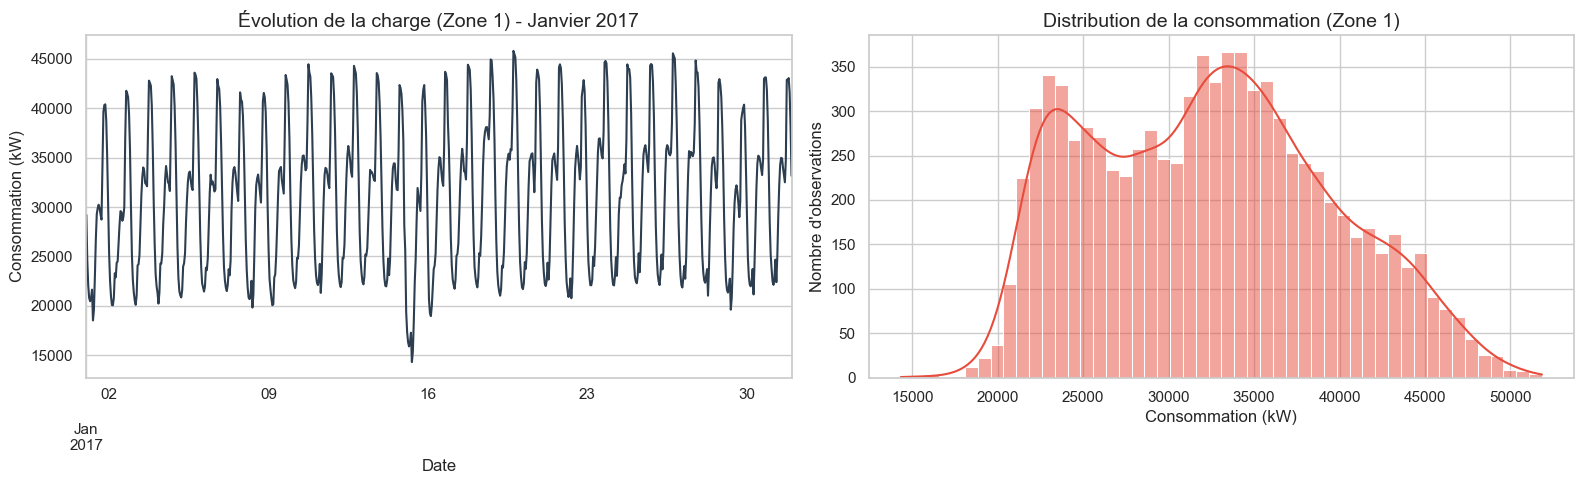

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_hourly["target"].loc["2017-01-01":"2017-01-31"].plot(
    ax=axes[0],
    color="#2c3e50"
)
axes[0].set_title("Évolution de la charge (Zone 1) - Janvier 2017")
axes[0].set_ylabel("Consommation (kW)")
axes[0].set_xlabel("Date")

sns.histplot(
    df_hourly["target"],
    bins=50,
    kde=True,
    ax=axes[1],
    color="#e74c3c"
)
axes[1].set_title("Distribution de la consommation (Zone 1)")
axes[1].set_xlabel("Consommation (kW)")
axes[1].set_ylabel("Nombre d'observations")

plt.tight_layout()
plt.savefig(FIG_DIR / "dynamique_et_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Les statistiques descriptives

In [5]:
desc_stats = df_hourly[
    ["zone1_power", "zone2_power", "zone3_power", "target", "total_load"]
].describe().T

display(desc_stats)

Path("../results/tables").mkdir(parents=True, exist_ok=True)
desc_stats.to_csv("../results/tables/statistiques_descriptives_hourly.csv")

,count,mean,std,min,25%,50%,75%,max
zone1_power,8736.0,32344.970564,7068.919876,14329.113923,26292.951730,32342.303347,37318.002218,51844.261932
zone2_power,8736.0,21042.509082,5165.178202,8685.947047,17016.901716,20787.229493,24677.609019,36254.699050
zone3_power,8736.0,17835.406218,6591.013989,6190.636254,13148.470246,16427.659642,21598.447824,47223.765690
target,8736.0,32344.970564,7068.919876,14329.113923,26292.951730,32342.303347,37318.002218,51844.261932
total_load,8736.0,71222.885864,17017.672977,37407.598328,56585.362485,69904.998137,83781.626500,133129.826080


## Comparaison des trois zones

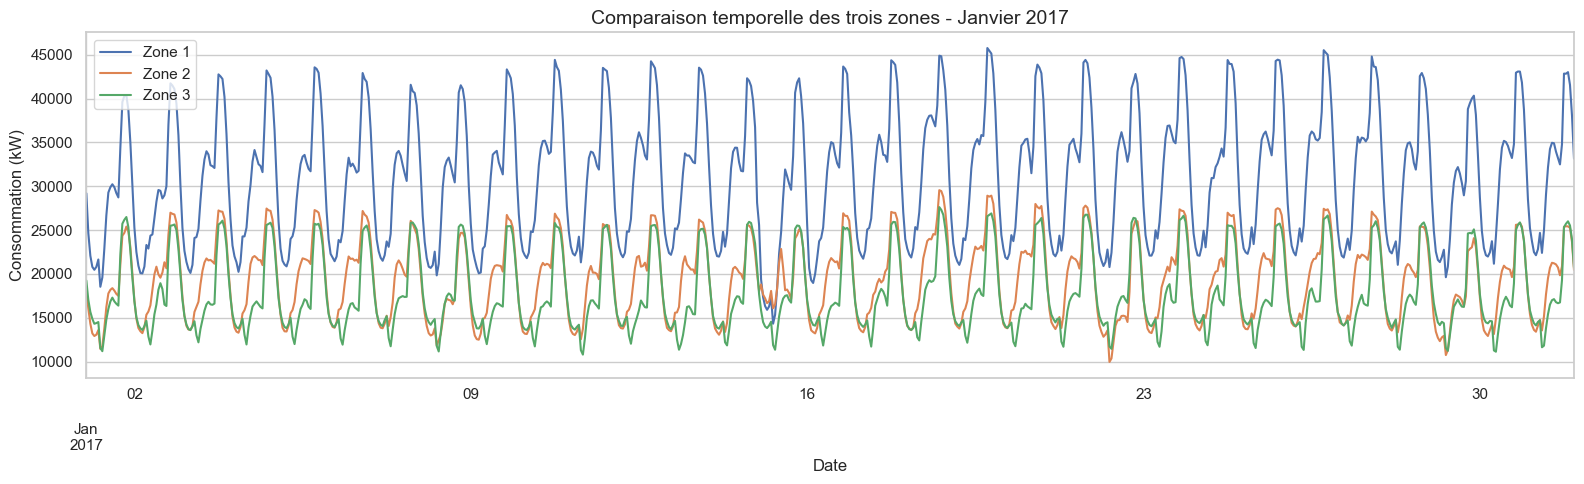

In [6]:
plt.figure(figsize=(16, 5))

df_hourly[["zone1_power", "zone2_power", "zone3_power"]].loc[
    "2017-01-01":"2017-01-31"
].plot(ax=plt.gca())

plt.title("Comparaison temporelle des trois zones - Janvier 2017")
plt.ylabel("Consommation (kW)")
plt.xlabel("Date")
plt.legend(["Zone 1", "Zone 2", "Zone 3"])

plt.tight_layout()
plt.savefig(FIG_DIR / "comparaison_zones_janvier.png", dpi=150, bbox_inches="tight")
plt.show()

## Profils temporels
Profils d'activité humaine (Extraction de la temporalité)

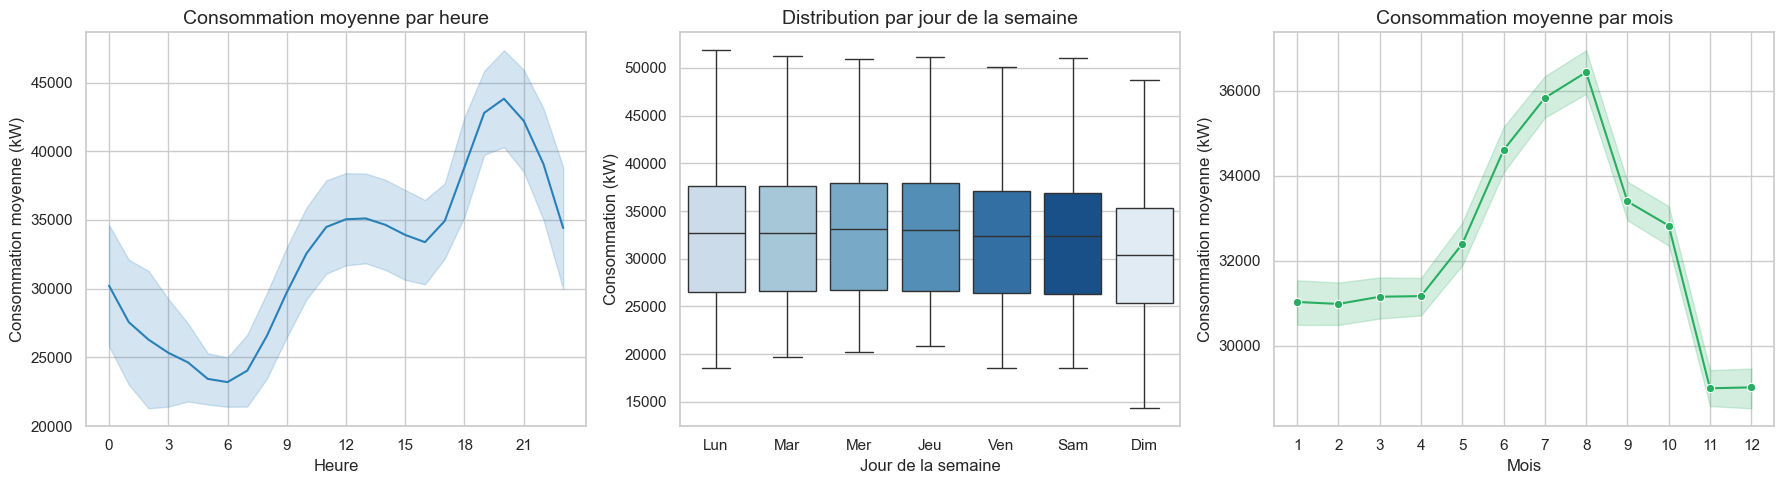

In [7]:
df_eda = df_hourly.copy()

df_eda["hour"] = df_eda.index.hour
df_eda["dayofweek"] = df_eda.index.dayofweek
df_eda["month"] = df_eda.index.month

weekday_order = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]
weekday_map = {
    0: "Lun",
    1: "Mar",
    2: "Mer",
    3: "Jeu",
    4: "Ven",
    5: "Sam",
    6: "Dim"
}
df_eda["weekday"] = df_eda["dayofweek"].map(weekday_map)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(
    data=df_eda,
    x="hour",
    y="target",
    ax=axes[0],
    errorbar="sd",
    color="#2980b9"
)
axes[0].set_title("Consommation moyenne par heure")
axes[0].set_xticks(range(0, 24, 3))
axes[0].set_xlabel("Heure")
axes[0].set_ylabel("Consommation moyenne (kW)")

sns.boxplot(
    data=df_eda,
    x="weekday",
    y="target",
    order=weekday_order,
    ax=axes[1],
    palette="Blues",
    hue="weekday",
    legend=False
)
axes[1].set_title("Distribution par jour de la semaine")
axes[1].set_xlabel("Jour de la semaine")
axes[1].set_ylabel("Consommation (kW)")

sns.lineplot(
    data=df_eda,
    x="month",
    y="target",
    ax=axes[2],
    color="#27ae60",
    marker="o"
)
axes[2].set_title("Consommation moyenne par mois")
axes[2].set_xticks(range(1, 13))
axes[2].set_xlabel("Mois")
axes[2].set_ylabel("Consommation moyenne (kW)")

plt.tight_layout()
plt.savefig(FIG_DIR / "profils_temporels.png", dpi=150, bbox_inches="tight")
plt.show()

## Heatmap heure × jour

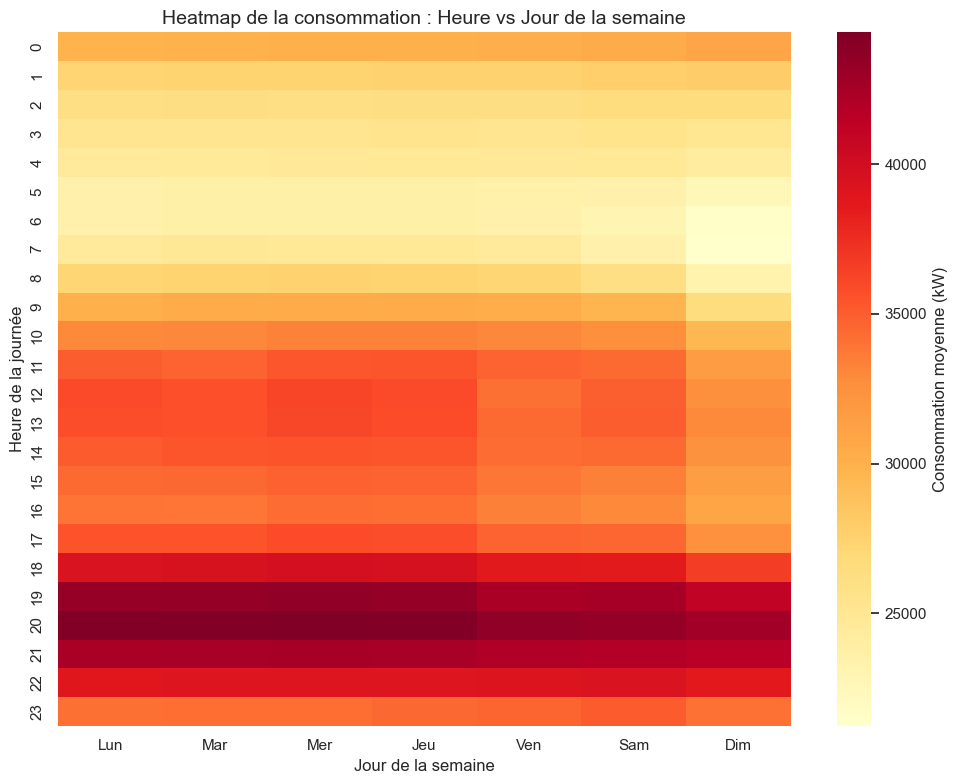

In [8]:
pivot_table = df_eda.pivot_table(
    values="target",
    index="hour",
    columns="weekday",
    aggfunc="mean"
).reindex(columns=weekday_order)

plt.figure(figsize=(10, 8))

sns.heatmap(
    pivot_table,
    cmap="YlOrRd",
    annot=False,
    fmt=".0f",
    cbar_kws={"label": "Consommation moyenne (kW)"}
)

plt.title("Heatmap de la consommation : Heure vs Jour de la semaine")
plt.ylabel("Heure de la journée")
plt.xlabel("Jour de la semaine")

plt.tight_layout()
plt.savefig(FIG_DIR / "heatmap_heure_jour.png", dpi=150, bbox_inches="tight")
plt.show()

## Corrélation météo-consommation

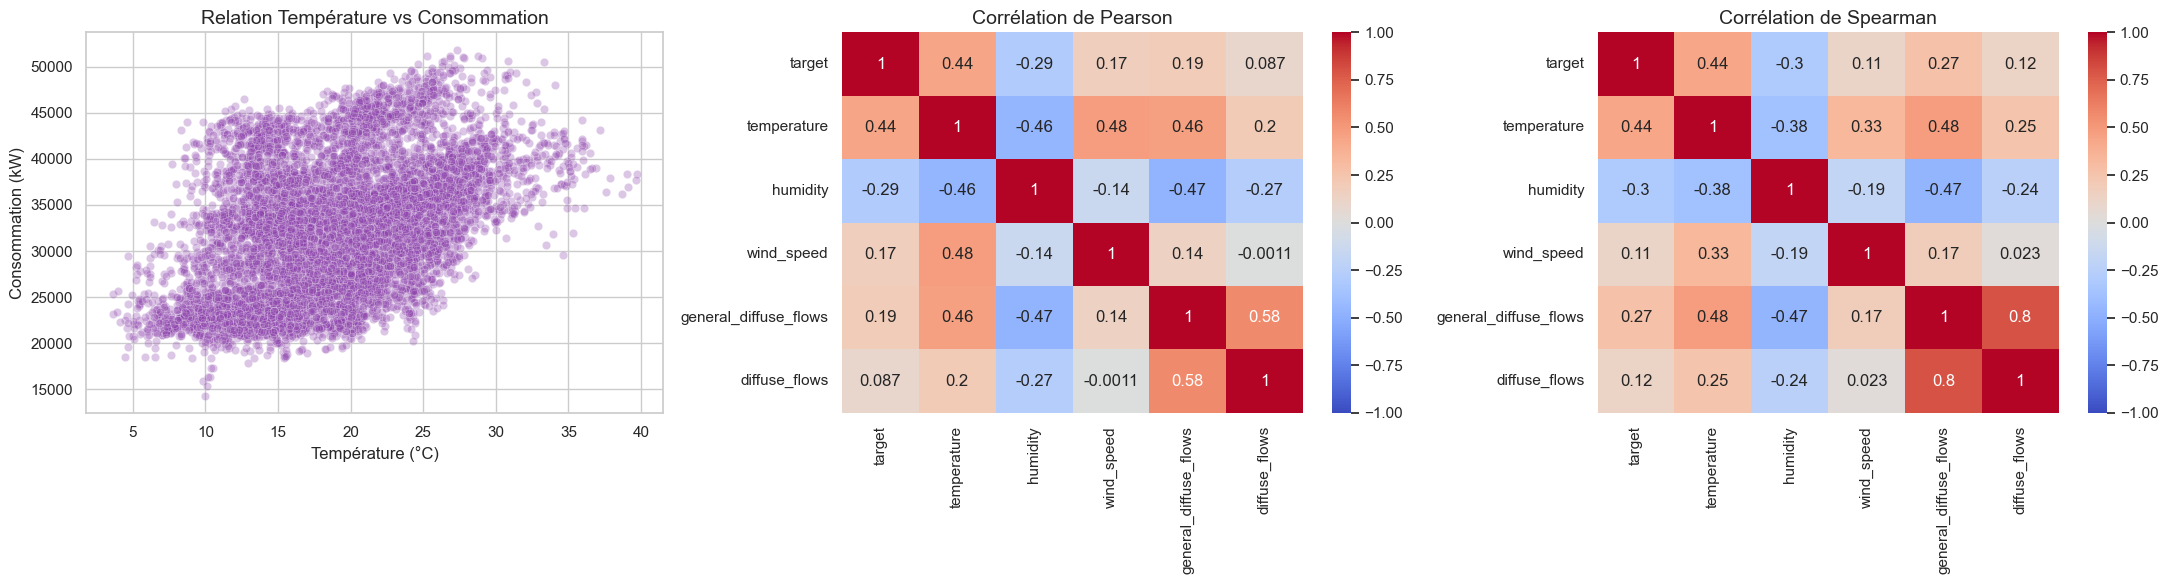

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.scatterplot(
    data=df_eda,
    x="temperature",
    y="target",
    alpha=0.3,
    ax=axes[0],
    color="#8e44ad"
)
axes[0].set_title("Relation Température vs Consommation")
axes[0].set_xlabel("Température (°C)")
axes[0].set_ylabel("Consommation (kW)")

cols_to_corr = [
    "target",
    "temperature",
    "humidity",
    "wind_speed",
    "general_diffuse_flows",
    "diffuse_flows"
]

corr_pearson = df_eda[cols_to_corr].corr(method="pearson")
corr_spearman = df_eda[cols_to_corr].corr(method="spearman")

sns.heatmap(
    corr_pearson,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    ax=axes[1]
)
axes[1].set_title("Corrélation de Pearson")

sns.heatmap(
    corr_spearman,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    ax=axes[2]
)
axes[2].set_title("Corrélation de Spearman")

plt.tight_layout()
plt.savefig(FIG_DIR / "meteo_correlation_pearson_spearman.png", dpi=150, bbox_inches="tight")
plt.show()

## La décomposition STL

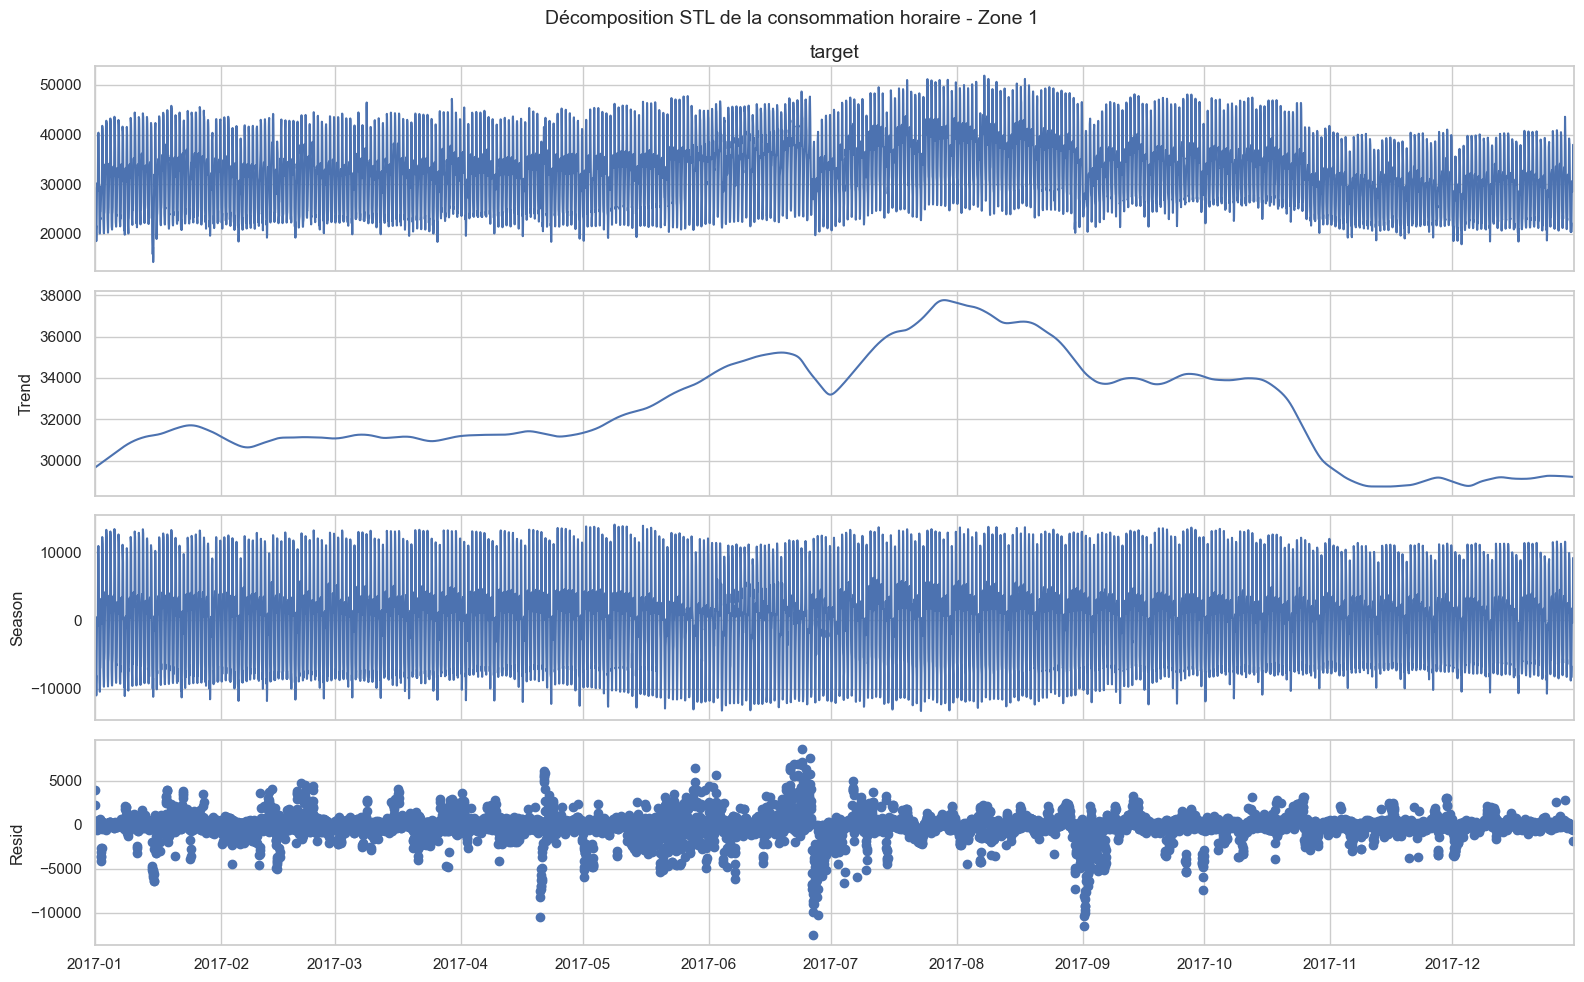

In [10]:
target_series = df_hourly["target"].dropna()

stl = STL(target_series, period=168, robust=True)
stl_result = stl.fit()

fig = stl_result.plot()
fig.set_size_inches(16, 10)

plt.suptitle("Décomposition STL de la consommation horaire - Zone 1", fontsize=14)
plt.tight_layout()

plt.savefig(FIG_DIR / "stl_decomposition_zone1.png", dpi=150, bbox_inches="tight")
plt.show()

## ACF/PACF
Mémoire de la série (ACF et PACF) pour les modèles Auto-régressifs

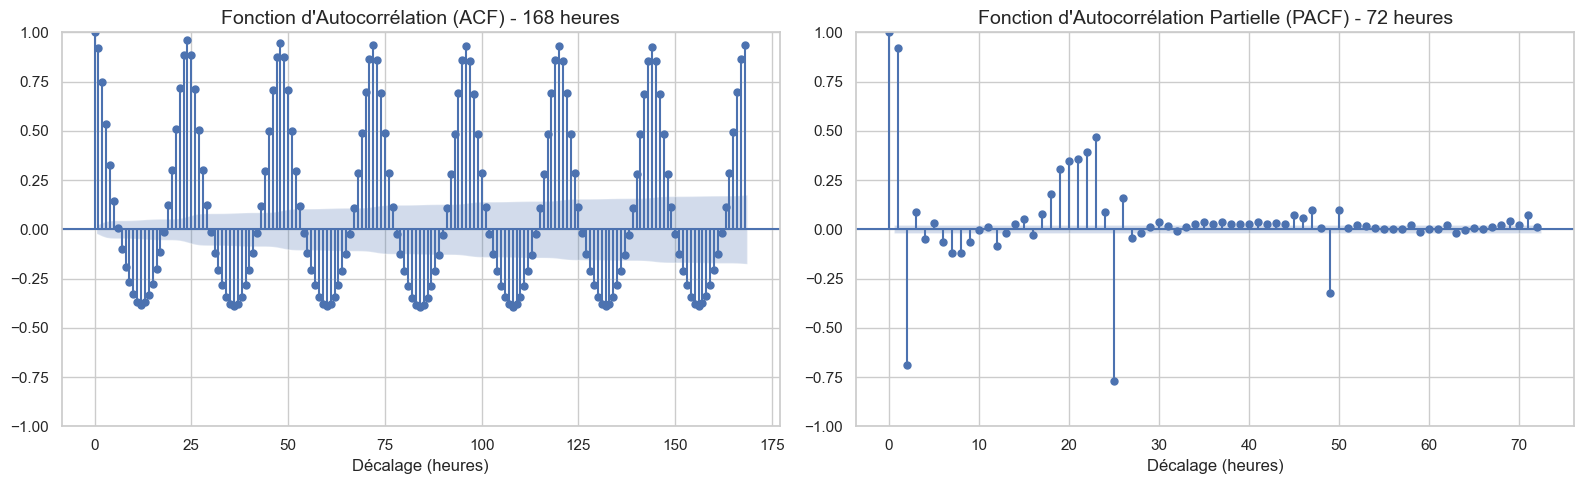

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(
    df_hourly["target"].dropna(),
    lags=168,
    ax=axes[0],
    alpha=0.05
)
axes[0].set_title("Fonction d'Autocorrélation (ACF) - 168 heures")
axes[0].set_xlabel("Décalage (heures)")

plot_pacf(
    df_hourly["target"].dropna(),
    lags=72,
    ax=axes[1],
    alpha=0.05,
    method="ywm"
)
axes[1].set_title("Fonction d'Autocorrélation Partielle (PACF) - 72 heures")
axes[1].set_xlabel("Décalage (heures)")

plt.tight_layout()
plt.savefig(FIG_DIR / "acf_pacf.png", dpi=150, bbox_inches="tight")
plt.show()

## Détection exploratoire des anomalies

Nombre d'anomalies détectées : 0


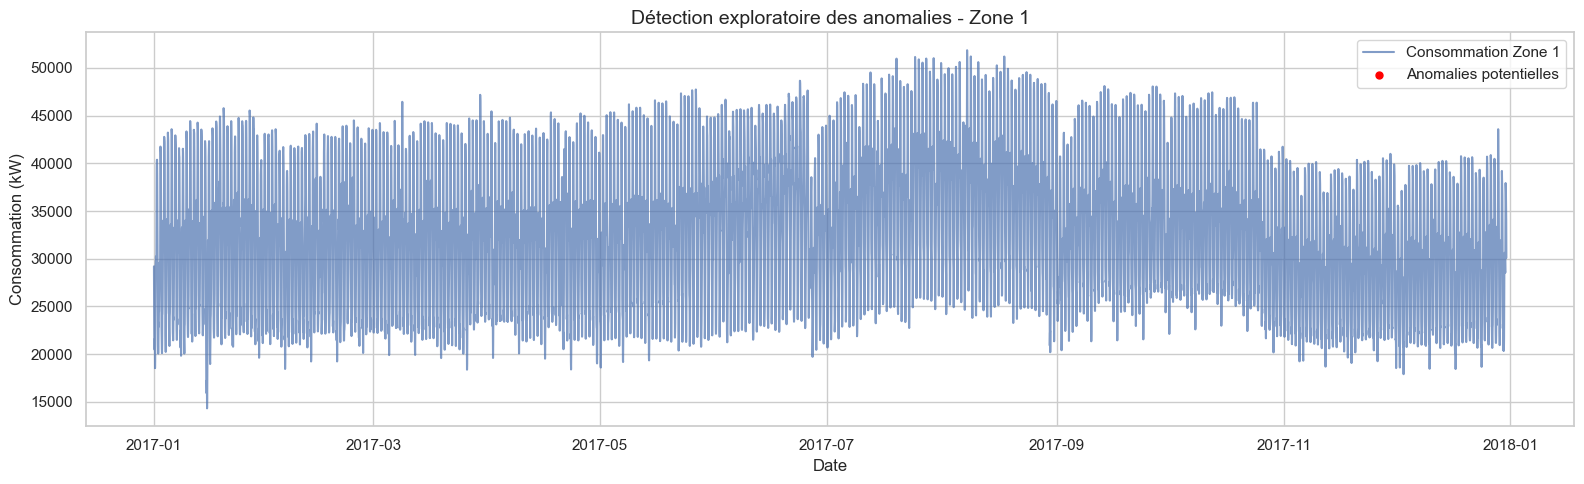

In [12]:
rolling_window = 168  # une semaine

rolling_mean = df_hourly["target"].rolling(
    window=rolling_window,
    center=True,
    min_periods=24
).mean()

rolling_std = df_hourly["target"].rolling(
    window=rolling_window,
    center=True,
    min_periods=24
).std()

z_score = (df_hourly["target"] - rolling_mean) / rolling_std

anomalies = df_hourly[z_score.abs() > 3]

print(f"Nombre d'anomalies détectées : {len(anomalies)}")

plt.figure(figsize=(16, 5))

plt.plot(
    df_hourly.index,
    df_hourly["target"],
    label="Consommation Zone 1",
    alpha=0.7
)

plt.scatter(
    anomalies.index,
    anomalies["target"],
    color="red",
    label="Anomalies potentielles",
    s=25
)

plt.title("Détection exploratoire des anomalies - Zone 1")
plt.xlabel("Date")
plt.ylabel("Consommation (kW)")
plt.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "anomalies_zone1.png", dpi=150, bbox_inches="tight")
plt.show()